<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Bradford%20Cornell%20%26%20Aswath%20Damodaran%20(2020)%20The%20Big%20Market%20Delusion_%20Valuation%20and%20Investment%20Implications/The_Big_Market_Delusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

# The Big Market Delusion (Cornell & Damodaran, 2020)

## Core Idea:
Companies often justify high valuations using **Total Addressable Market (TAM)**.
This paper argues:
- TAM is often **overstated**
- Firms cannot capture the entire market
- **Competition + economics** limit actual value

We will simulate:
1. TAM vs realistic revenue
2. Market share constraints
3. Margin + reinvestment realities
4. Valuation implications

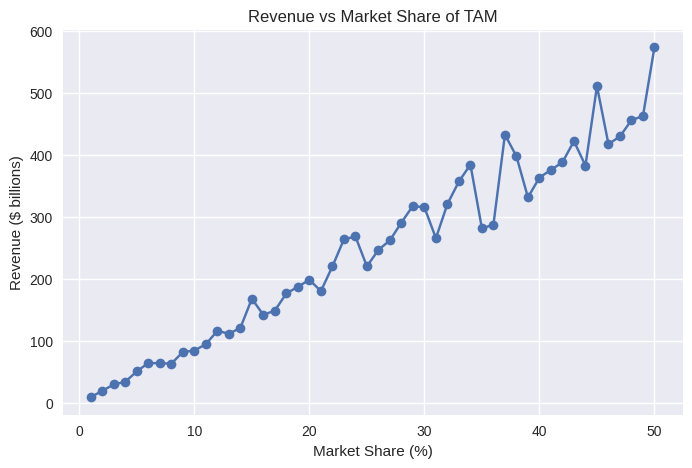

In [8]:
tam = 1_000_000_000_000  # $1 trillion

# realistic capture rates: mostly low, few high
capture_rates = np.linspace(0.01, 0.5, 50)
revenues = tam * capture_rates * np.random.uniform(0.8,1.2, size=capture_rates.shape)

plt.figure(figsize=(8,5))
plt.plot(capture_rates*100, revenues/1e9, marker='o')
plt.xlabel("Market Share (%)")
plt.ylabel("Revenue ($ billions)")
plt.title("Revenue vs Market Share of TAM")
plt.grid(True)
plt.show()

### Insight:
Even small changes in assumed market share dramatically affect valuation narratives.
Most pitches implicitly assume unrealistically high capture rates.

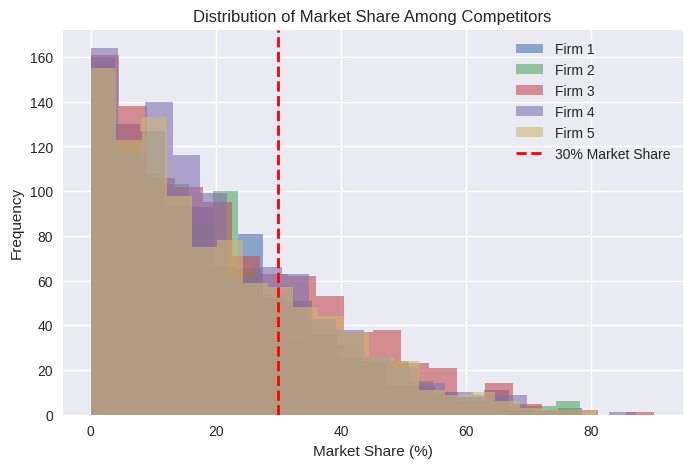

In [13]:
num_firms = 5
samples = 1000

# random market shares using Dirichlet
realistic_shares = np.random.dirichlet(np.ones(num_firms), size=samples)

plt.figure(figsize=(8,5))
for i in range(num_firms):
    plt.hist(realistic_shares[:,i]*100, bins=20, alpha=0.6, label=f'Firm {i+1}')
plt.axvline(x=30, color='red', linestyle='--', linewidth=2, label='30% Market Share')
plt.xlabel("Market Share (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Market Share Among Competitors")
plt.legend()
plt.show()

### Insight:
- Markets rarely go to one winner
- Even strong firms may only capture **10–30%**

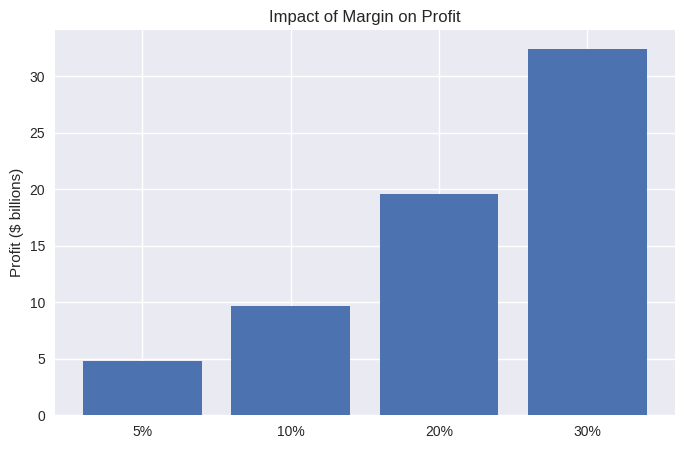

In [10]:
revenue = 100_000_000_000  # $100B
margins = [0.05, 0.1, 0.2, 0.3]
profits = [revenue * m * np.random.uniform(0.9,1.1) for m in margins]  # add some variation

plt.figure(figsize=(8,5))
plt.bar([str(int(m*100))+'%' for m in margins], [p/1e9 for p in profits])
plt.ylabel("Profit ($ billions)")
plt.title("Impact of Margin on Profit")
plt.show()

### Insight:
High TAM does NOT imply high profits.
Margins compress due to:
- Competition
- Pricing pressure
- Regulation

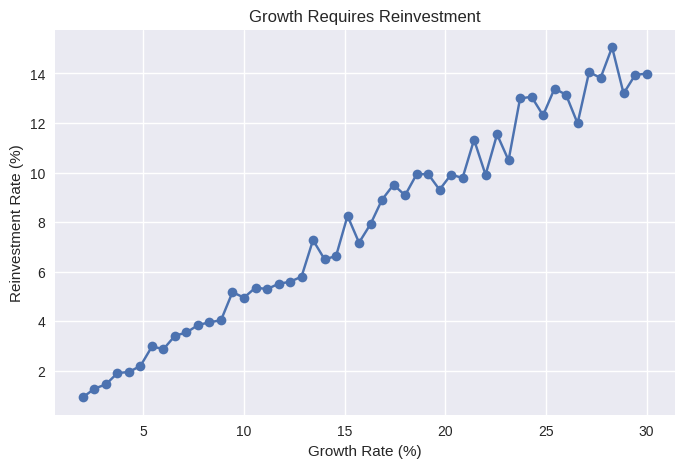

In [11]:
growth_rates = np.linspace(0.02, 0.3, 50)
sales_to_capital = 2
reinvestment = growth_rates / sales_to_capital * np.random.uniform(0.9,1.1, size=growth_rates.shape)

plt.figure(figsize=(8,5))
plt.plot(growth_rates*100, reinvestment*100, marker='o')
plt.xlabel("Growth Rate (%)")
plt.ylabel("Reinvestment Rate (%)")
plt.title("Growth Requires Reinvestment")
plt.grid(True)
plt.show()

### Insight:
Growth is NOT free.
High growth requires heavy reinvestment → lowers cash flow.

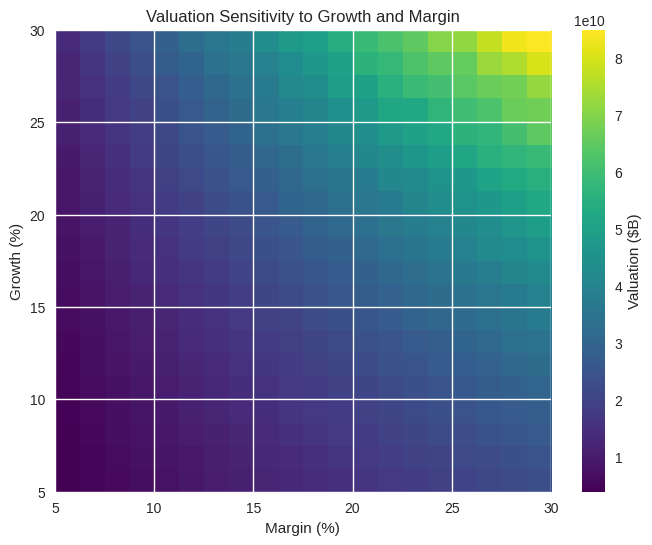

In [12]:
def simple_dcf(revenue, margin, growth, discount_rate, years=10):
    cashflows = []
    current_revenue = revenue
    for t in range(years):
        current_revenue *= (1 + growth*np.random.uniform(0.95,1.05))  # vary growth per year
        profit = current_revenue * margin
        cashflows.append(profit / ((1 + discount_rate) ** (t+1)))
    return sum(cashflows)

growth_vals = np.linspace(0.05, 0.3, 20)
margin_vals = np.linspace(0.05, 0.3, 20)
valuation_grid = np.zeros((20,20))

for i, g in enumerate(growth_vals):
    for j, m in enumerate(margin_vals):
        valuation_grid[i,j] = simple_dcf(10e9, m, g, 0.1)

plt.figure(figsize=(8,6))
plt.imshow(valuation_grid, extent=[5,30,5,30], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label="Valuation ($B)")
plt.xlabel("Margin (%)")
plt.ylabel("Growth (%)")
plt.title("Valuation Sensitivity to Growth and Margin")
plt.show()

### Insight:

Small optimism in growth, margins, or market share assumptions can lead to massive overvaluation. Valuation is extremely sensitive to these inputs, and “TAM narratives” often embed overly optimistic projections that exaggerate a company’s potential.


# Key Lessons from the Paper

1. TAM is NOT value
2. Market share is constrained by competition
3. High growth requires reinvestment
4. Margins tend to decline in large markets
5. Valuation must be grounded in fundamentals

## Bottom Line:
Narratives ≠ Valuation